In [52]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # 
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"}

model = pybamm.lithium_ion.SPM(options=options)

In [53]:
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })

In [54]:
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3 
    EaD = 20000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius
parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})

In [ ]:
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*3}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 38000.0}) 

In [56]:
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.5*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })






In [57]:
#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.0001,
                        
                        })


In [58]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [59]:
from itertools import product

temp_list2 = [10, 25, 45]
soc_list2 = [30, 60, 100]

calendar_cases = list(product(temp_list2, soc_list2))

df22 = pd.DataFrame(calendar_cases, columns= ["Temperature", "SoC"])
df22.insert(0, "Case", range(1, len(df22)+1))
df22.to_csv(f"{current_directory}/paperstudies2026/calendarStudies/Cases_for_Calendar_ageing.csv", index=False)


In [60]:
df22

,Case,Temperature,SoC
0,1,10,30
1,2,10,60
2,3,10,100
3,4,25,30
4,5,25,60
5,6,25,100
6,7,45,30
7,8,45,60
8,9,45,100


In [61]:
# experiment01 = pybamm.Experiment(["Discharge at 0.1C until 2.5V"])
# sim = pybamm.Simulation(model, experiment=experiment01, parameter_values=parameter_values) #,experiment=experiment
# #sim = pybamm.Simulation(model)
# sim.solve() #initial_soc=0.5, t_eval=[0,3700]
# sim.plot()

In [62]:
# Qcell = sim.solution["Discharge capacity [A.h]"].entries
# Vcell = sim.solution["Voltage [V]"].entries
# plt.figure()
# plt.plot( Qcell,Vcell)
# #plt.plot(tt,Qcell )
# plt.ylabel('Voltage [V]',fontsize=20)
# plt.xlabel('Capacity [A.h]',fontsize=20)
# plt.xticks(fontsize=18)
# plt.yticks(fontsize=18)

### Code to get V vs SoC for calendar ageing soC interpolation.

In [63]:
# df_Vvssoc = {}
# df_Vvssoc = pd.DataFrame(df_Vvssoc)
# df_Vvssoc["soc"] = 1-Qcell/Qcell[-1]
# df_Vvssoc["Vcell"] = Vcell

# df_Vvssoc.to_csv(f"{current_directory}wip/paperstudies2026/calendarStudies/QvsV01C.csv")

In [64]:
df01c = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/QvsV01C.csv")

x01c = df01c["soc"].to_numpy()
y01c = df01c["Vcell"].to_numpy()
x01c_scaled = (x01c-x01c.min())/(x01c.max()-x01c.min())
# idx = np.argsort(x01c_scaled)
# y01c = y01c[idx]

# x_new = 0.7
# y_new = np.interp(x_new, x01c_scaled, y01c)

x01c_unique, unique_idx = np.unique(x01c_scaled, return_index=True)
y01c_unique = y01c[unique_idx]
x_new1 = 1
y_new1 = np.interp(x_new1, x01c_unique, y01c_unique)
print(y_new1)

4.167864419417144


## Studies for calendar ageing

Cycling: 100%|██████████| 13/13 [00:00<00:00, 56.05it/s]


Took 18.404 ms


Cycling: 100%|██████████| 13/13 [00:00<00:00, 54.60it/s]


Took 17.721 ms


Cycling: 100%|██████████| 13/13 [00:00<00:00, 54.19it/s]


...

Took 8.237 ms


Cycling:  15%|█▌        | 2/13 [00:00<00:00, 19.41it/s]2026-03-02 05:36:15.032 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Rest for 720 hours (60 minute period)'. The returned solution only contains up to step 1 of cycle 3. 
Cycling:  15%|█▌        | 2/13 [00:00<00:00, 16.15it/s]


Took 9.482 ms


Cycling:   8%|▊         | 1/13 [00:00<00:03,  3.25it/s]2026-03-02 05:36:16.237 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Rest for 720 hours (60 minute period)'. The returned solution only contains up to step 1 of cycle 3. 
Cycling:  15%|█▌        | 2/13 [00:00<00:01,  5.86it/s]

Took 7.596 ms


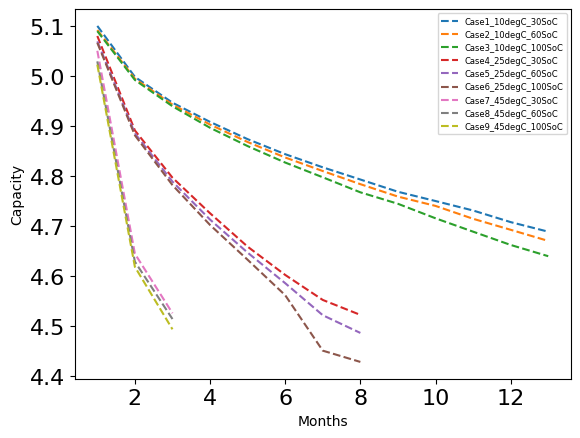

In [65]:
cycles_per_day = 1
days_per_year = 365 #365
months_per_year = 12
years_for_sim = 1
days_per_month = 30 #days
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
#soc_upper_cutoff = 1
#soc_lower_cutoff = 0
#max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver() #mode="safe", ,  dt_max= dt_max


simcase_list = []
experiment_list = []
no_steps_list = []

for n in range(len(df22)): #[4]
    tempC_case = df22["Temperature"][n]
    simcase = df22["Case"][n]
    
    soc_case = df22["SoC"][n]*0.01
    
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    t_soc_char = (soc_case)*60/crate_ref
    v0_soc_case = np.interp(soc_case, x01c_unique, y01c_unique)
    # exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
    # sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    # sol0 = sim0.solve()

    # if soc_case == 1:
    #     model1 = model  #.set_initial_conditions_from(sol0)
    # else:
    exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C until {v0_soc_case}V")])
    sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    sol0 = sim0.solve()
    model1 = model.set_initial_conditions_from(sol0)
        

    #discharge_time = int(60/crate*dod_case) # in minutes
    #charge_time = int(60/crate*dod_case) # in minutes
    #rest_time = int(time_per_cycle*60*calendar_time) #- discharge_time - charge_time
   

    discharge_string = f"Discharge at {crate_ref}C until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate_ref}C until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {days_per_month*24} hours ({period_rest} minute period)"
    charge_string_initialsoc = f"Charge at {crate_ref}C until {v0_soc_case}V"


    
    #list_of_steps_auto = list([rest_string, charge_string, discharge_string, charge_string_initialsoc])
    list_of_steps_auto = list([rest_string])

    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {days_per_month} days calendaring for each cycle")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    exp1 = pybamm.Experiment(["Rest for 1 minute"]+list_of_steps_auto*months_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Months"] =cycle1/(steps_total)-1 #*days_per_month
    df2["Capacity"] = Q1
    df2.to_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")

    plt.plot(cycle1/(steps_total),Q1,"--", label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")
    plt.legend(fontsize=6)

plt.xlabel("Months")
plt.ylabel("Capacity")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
df_conditions["simcase"] = simcase_list
df_conditions["Experiment"] = experiment_list
df_conditions["n_steps"] = no_steps_list

df_conditions.to_csv(f"{current_directory}/paperstudies2026/calendarStudies/experiments_calendar.csv")



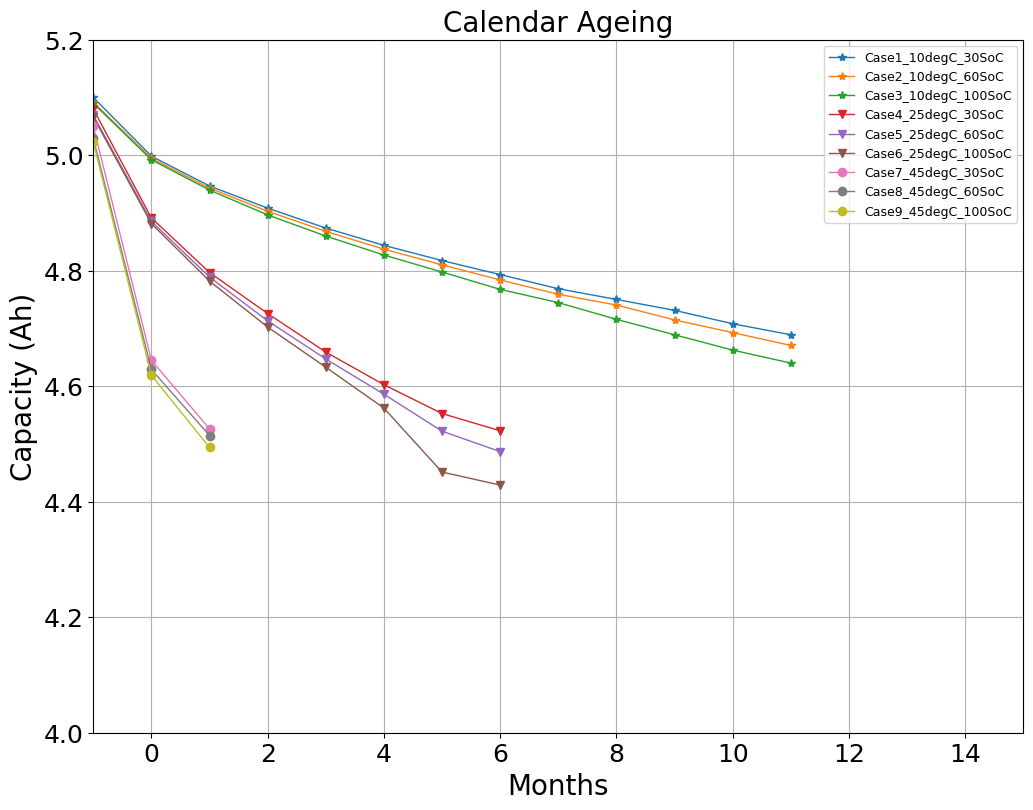

In [66]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Cases_for_Calendar_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(12,9))
b =0
# for m in [5,11,12,13,15,17,23,27]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='v', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in range(3): #33,49, #range(27,54):#: #range(5): #
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='*', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(3,6): #33,49, #range(27,54):#: #range(5): #
    
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='v', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(6,9): #33,49, #range(27,54):#: #range(5): #
    
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='o', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

# for m in [59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='o', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Months',fontsize=20)
plt.ylabel('Capacity (Ah)',fontsize=20)
plt.title('Calendar Ageing',fontsize=20)
plt.ylim([4.0, 5.2])
plt.xlim([-1, 15])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

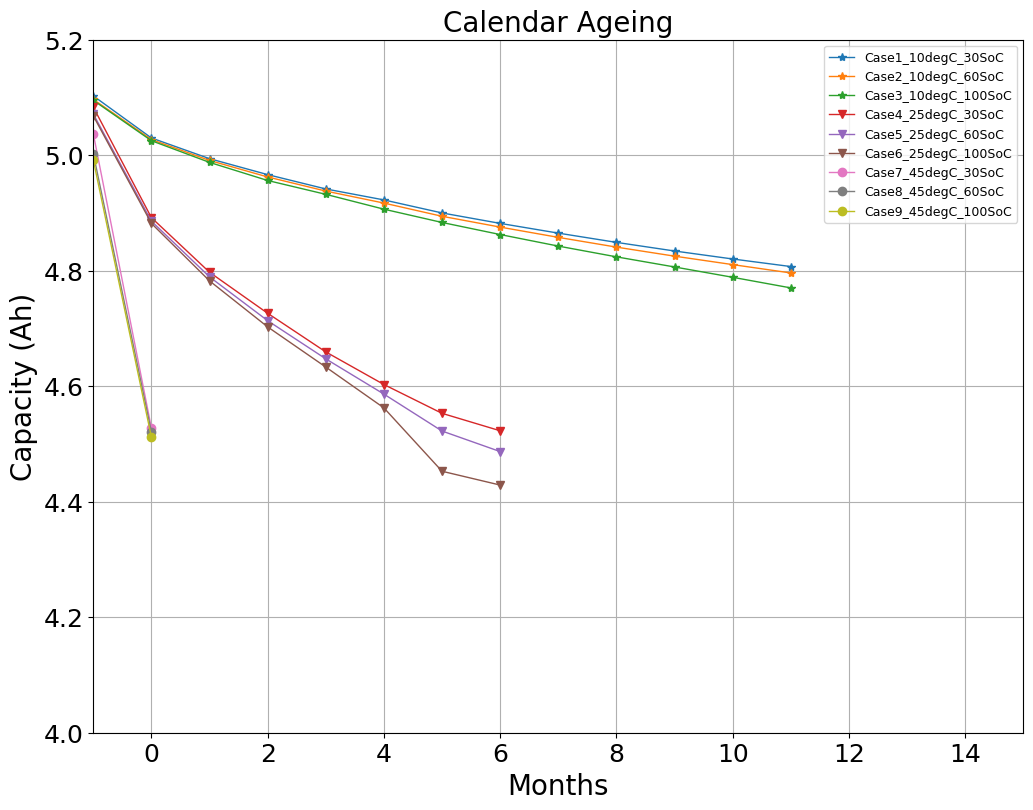

In [ ]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Cases_for_Calendar_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(12,9))
b =0
# for m in [5,11,12,13,15,17,23,27]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='v', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in range(3): #33,49, #range(27,54):#: #range(5): #
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='*', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(3,6): #33,49, #range(27,54):#: #range(5): #
    
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='v', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(6,9): #33,49, #range(27,54):#: #range(5): #
    
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/calendarStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='o', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

# for m in [59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='o', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Months',fontsize=20)
plt.ylabel('Capacity (Ah)',fontsize=20)
plt.title('Calendar Ageing',fontsize=20)
plt.ylim([4.0, 5.2])
plt.xlim([-1, 15])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

In [ ]:
#sim1.plot()
#sol1.save("DFN_300cyl_fail-sol.pkl")

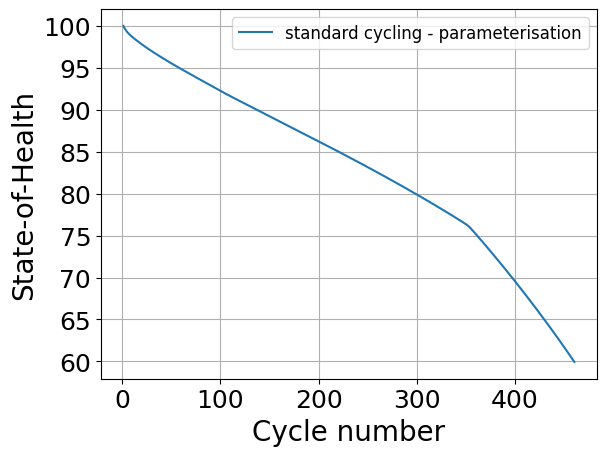

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

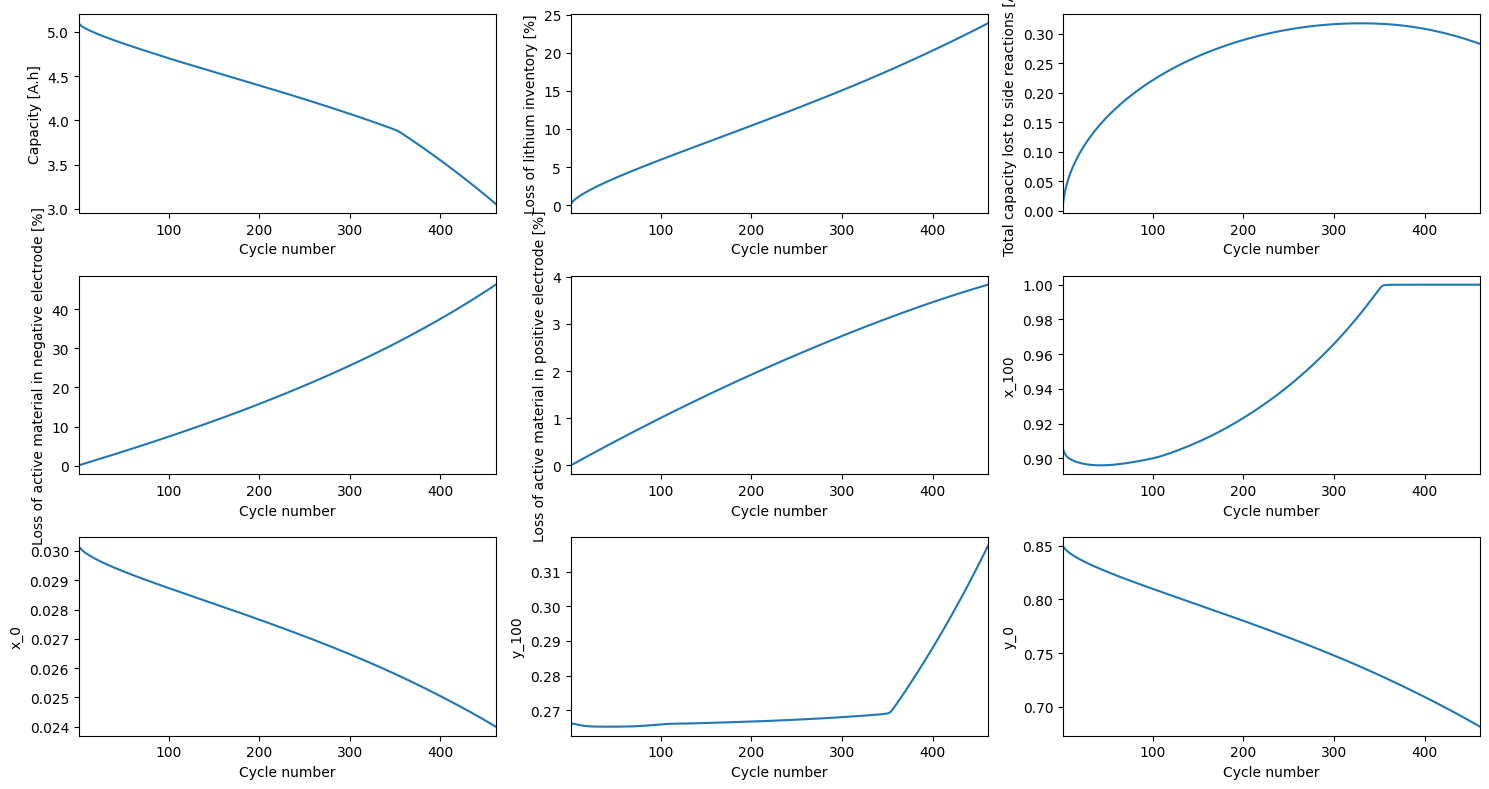

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [ ]:
pybamm.plot_summary_variables(sim1.solution)

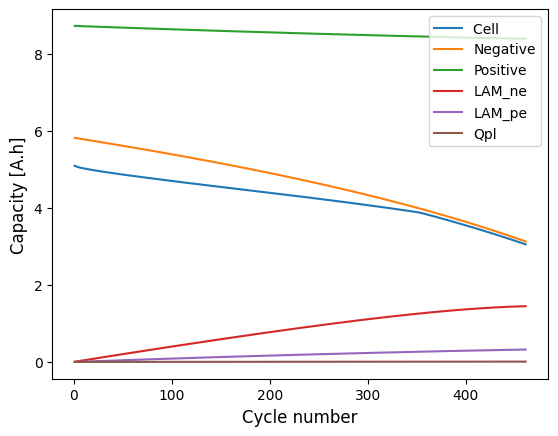

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()
